In [31]:
import numpy as np
from matplotlib import pyplot as plt
# plt.switch_backend('Agg')

In [32]:
class ConcurrentLearningStack:
    def __init__(self, num_states, num_features, max_capacity=10, tolerance=1e-3):
        """
        Manages the history stack for Concurrent Learning.
        num_states: Dimension of X (p)
        num_features: Dimension of theta (m)
        max_capacity: Number of orthogonal points to store (P)
        tolerance: Minimum Frobenius norm difference required to record new data
        """
        self.max_capacity = max_capacity
        self.tolerance = tolerance
        
        # Pre-allocate history tensors
        # X_hist shape: (P, num_states, 1)
        # Z_hist shape: (P, num_states, num_features)
        self.X_hist = np.zeros((max_capacity, num_states, 1))
        self.Z_hist = np.zeros((max_capacity, num_states, num_features))
        
        self.current_size = 0
        self.head_index = 0  # Pointer for the FIFO cyclic overwrite
        self.last_added_Z = None

    def _check_richness(self, Z):
        """Evaluates if the new regressor Z is geometrically distinct."""
        if self.current_size == 0:
            return True
            
        # Frobenius norm measures the spatial difference between matrices
        diff = np.linalg.norm(Z - self.last_added_Z, ord='fro')
        return diff > self.tolerance

    def update(self, X, Z):
        """
        Attempt to add a new (X, Z) pair to the stack.
        Returns True if accepted by the richness filter, False otherwise.
        """
        if not self._check_richness(Z):
            return False  # Reject data (robot is just sitting still or moving linearly)

        # Reshape X if it was passed as a flat array to maintain tensor math
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        if self.current_size < self.max_capacity:
            # Stack is not full yet; append to the end
            idx = self.current_size
            self.current_size += 1
        else:
            # Stack is full; overwrite the oldest data (FIFO)
            idx = self.head_index
            self.head_index = (self.head_index + 1) % self.max_capacity
            
        self.X_hist[idx] = X
        self.Z_hist[idx] = Z
        self.last_added_Z = np.copy(Z)
        
        return True

    def get_cl_gradient(self, theta_hat):
        """
        Calculates the concurrent learning parameter update term.
        Mathematically: sum(Z_j^T * (X_j - Z_j * theta_hat))
        """
        if self.current_size == 0:
            return np.zeros_like(theta_hat)
        
        # Slice only the valid data (important during the initial fill phase)
        Z_valid = self.Z_hist[:self.current_size]
        X_valid = self.X_hist[:self.current_size]
        
        # Vectorized batch prediction: (N, p, m) @ (m, 1) -> (N, p, 1)
        if theta_hat.ndim == 1:
            theta_hat = theta_hat.reshape(-1, 1)
        X_hat = Z_valid @ theta_hat
        
        # Batch error calculation: (N, p, 1)
        error = X_valid - X_hat
        
        # Batch gradient calculation: Z^T * error
        # Transpose the inner matrices of Z: (N, p, m) -> (N, m, p)
        Z_T = np.transpose(Z_valid, (0, 2, 1))
        
        # (N, m, p) @ (N, p, 1) -> (N, m, 1)
        gradients = Z_T @ error
        
        # Sum across the batch dimension to get the final (m, 1) update vector
        cl_grad = np.sum(gradients, axis=0)
        
        return cl_grad

    def check_persistent_excitation(self):
        """
        Calculates the minimum eigenvalue of the information matrix.
        Use this to verify your stack mathematically satisfies the PE condition.
        """
        if self.current_size == 0:
            return 0.0
            
        Z_valid = self.Z_hist[:self.current_size]
        Z_T = np.transpose(Z_valid, (0, 2, 1))
        
        # Omega = sum(Z^T * Z)
        Omega = np.sum(Z_T @ Z_valid, axis=0)
        
        eigenvalues = np.linalg.eigvals(Omega)
        return np.min(np.real(eigenvalues))

In [33]:
def f(x):
    return np.array([[0, 1], [0, 0]]) @ x

def g(x):
    return np.array([0, 1])

def F(x):
    return np.array([[0, 0], [-x[1], -np.tanh(x[1])]])

theta_true = np.array([0.5, 0.2])

def Delta(x,t): 
    return np.array([0, 0.3*np.sin(t)])

def observer_xhat_dot(xhat, x, u, theta_hat, y, L, C):
    return f(xhat) + g(xhat) @ u + F(xhat) @ theta_hat + L @ (y - C@xhat)

def compute_X(xhat_new, xhat_old, u_new, u_old, dt):
    old = f(xhat_old) + g(xhat_old) @ u_old
    new = f(xhat_new) + g(xhat_new) @ u_new
    return xhat_new - xhat_old - 0.5*dt*(old + new)

def compute_Z(xhat_new, xhat_old, dt):
    old = F(xhat_old)
    new = F(xhat_new)
    return 0.5*dt*(old + new)



In [36]:
np.random.seed(42)
x = np.zeros(2)
xhat = np.zeros(2)
theta_hat = np.zeros(2)

history_stack = ConcurrentLearningStack(num_states=2, num_features=2, max_capacity=10, tolerance=1e-3)

t = 0.0
dt = 0.1

C = np.eye(2)
L = 5*np.eye(2)  # Positive gain for stable observer

x_plotting = [np.copy(x)]
xhat_plotting = [np.copy(xhat)]
t_plotting = [t]
stack_eigenvalues = [history_stack.check_persistent_excitation()]

while t <= 5.0:
    y = C@x + np.random.normal(0, 0.1, size=2)
    u = np.zeros(2)  # Placeholder for control input (you would replace this with your actual control law
    xhat_dot = observer_xhat_dot(xhat, x, u, theta_hat, y, L, C)
    xhat_old = np.copy(xhat)
    xhat += xhat_dot * dt

    X = compute_X(xhat, xhat_old, u, u, dt)
    Z = compute_Z(xhat, xhat_old, dt)

    history_stack.update(X, Z)


    x += (f(x) + g(x) @ u + F(x) @ theta_true + Delta(x,t)) * dt

    t += dt
    x_plotting.append(np.copy(x))
    xhat_plotting.append(np.copy(xhat))
    t_plotting.append(t)
    stack_eigenvalues.append(history_stack.check_persistent_excitation())

print(history_stack.X_hist)

[[[ 0.02491846]
  [ 0.02399216]]

 [[-0.07083194]
  [-0.02945041]]

 [[ 0.02717038]
  [-0.14104719]]

 [[-0.01137314]
  [ 0.03387295]]

 [[-0.0732853 ]
  [-0.03206787]]

 [[ 0.04742185]
  [ 0.01261172]]

 [[-0.04875871]
  [ 0.00288455]]

 [[ 0.0041609 ]
  [ 0.01191728]]

 [[-0.03769564]
  [-0.07068011]]

 [[-0.00537863]
  [-0.10337291]]]


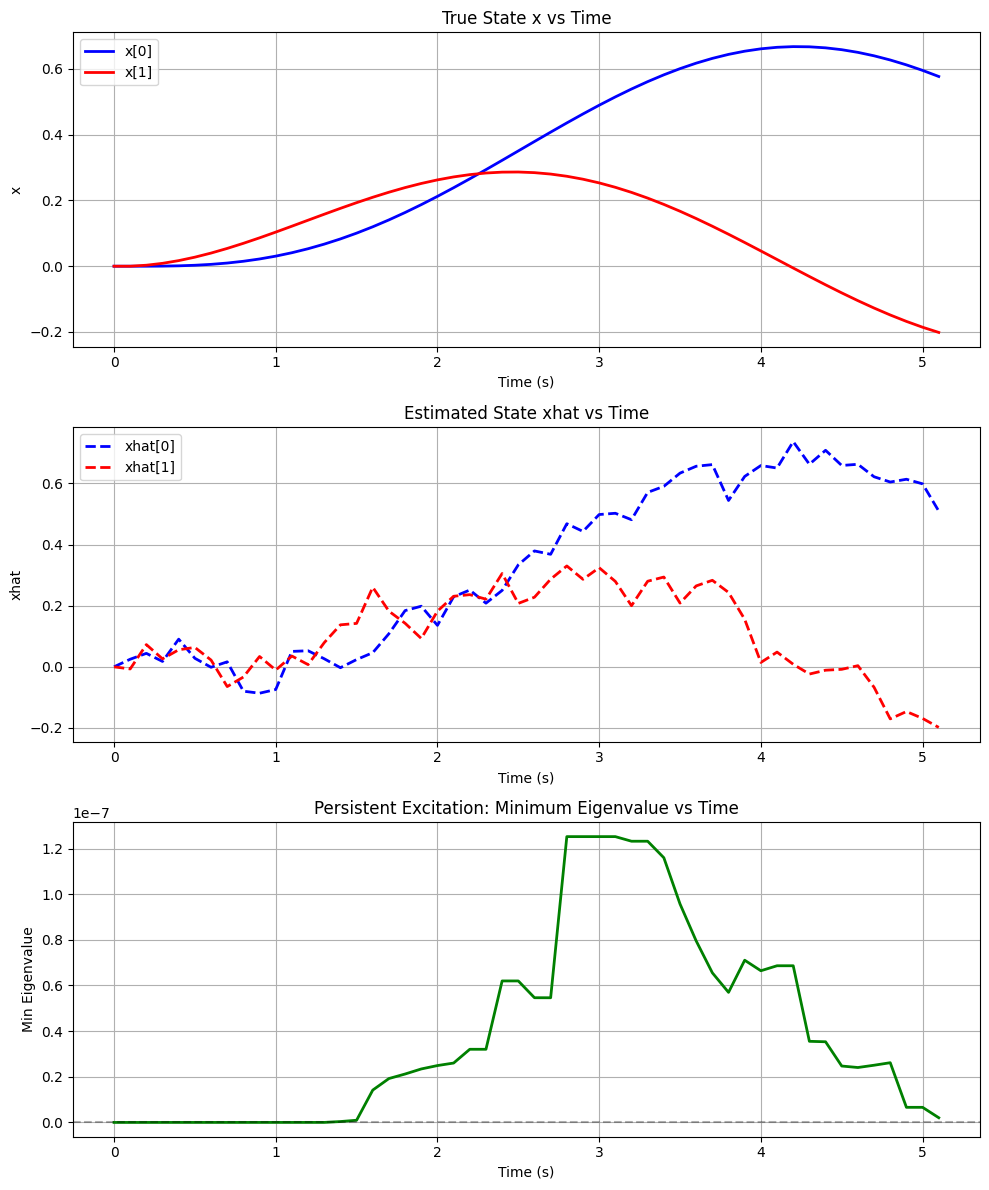

In [35]:
# Convert lists to arrays for easier plotting
x_history = np.array(x_plotting)
xhat_history = np.array(xhat_plotting)
t_history = np.array(t_plotting)
eigenvalue_history = np.array(stack_eigenvalues)

# Create 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# Plot x vs time
ax1.plot(t_history, x_history[:, 0], 'b-', label='x[0]', linewidth=2)
ax1.plot(t_history, x_history[:, 1], 'r-', label='x[1]', linewidth=2)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('x')
ax1.set_title('True State x vs Time')
ax1.legend()
ax1.grid(True)

# Plot xhat vs time
ax2.plot(t_history, xhat_history[:, 0], 'b--', label='xhat[0]', linewidth=2)
ax2.plot(t_history, xhat_history[:, 1], 'r--', label='xhat[1]', linewidth=2)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('xhat')
ax2.set_title('Estimated State xhat vs Time')
ax2.legend()
ax2.grid(True)

# Plot minimum eigenvalue vs time
ax3.plot(t_history, eigenvalue_history, 'g-', linewidth=2)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Min Eigenvalue')
ax3.set_title('Persistent Excitation: Minimum Eigenvalue vs Time')
ax3.grid(True)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('state_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
